# Curating Initial Populations via Tournament & Diversity-Rejection Sampling (opro-only)

Companion to `Multi_Tasks_Curating_Initial_Populations_By_Iteration_Budget.ipynb`. Reuses that
notebook's iteration-budget pooling (`load_pool_from_opro_runs_by_budget`, `TASK_BUDGET_CONFIGS`,
same per-task budgets/embed models/score filters/pop sizes) but swaps its score-quantile x
diversity-quantile grid sampler for two new within-budget sampling strategies.

**Tournament sampling.** To build a population of size N: run N rounds. Each round draws K
candidates uniformly at random (without replacement within the round) from the current active
pool, the highest-scoring contestant wins and joins the population, and only the winner is
removed from the active pool -- losers go back and can be redrawn in later rounds. Swept over 4
`K` values per `(task, budget)`, log-spaced between 2 and that pool's size, so thin budgets and
dense ones both get a meaningful K sweep instead of a fixed set that's meaningless for a
25-solution pool and barely explores a 2,000-solution one. **The largest `K` in every sweep is
always exactly the active pool's size** -- with K that large, each round's tournament draws the
whole remaining pool, so the winner is deterministically that pool's max score, i.e. fully greedy
top-N-by-score selection -- guaranteeing the sweep always includes that endpoint alongside the
more stochastic, smaller-K settings.

**Diversity-based rejection sampling.** A single descending-score pass over the active pool: the
top scorer is always taken first; every subsequent candidate (still walked in score order) is
compared by cosine similarity between its embedding and every already-accepted population
member's embedding, and is accepted only if its *maximum* similarity to the population doesn't
exceed a threshold `B` -- otherwise it's permanently skipped. This is a single pass, not a retry
queue, so it always terminates in O(pool_size) comparisons (a rejected candidate is never
reconsidered, which is also the only way "select the next-best top performer" can avoid
re-selecting the same rejected candidate forever). Swept over 4 `B` values per `(task, budget)`:
the first 3 are the 25/50/75th percentiles of that pool's own pairwise cosine-similarity
distribution, so "high similarity" means the same thing regardless of task/embedding model
(Qodo-Embed's code embeddings and MiniLM's sentence embeddings aren't on the same raw scale).
**The 4th, largest `B` in every sweep is always exactly `1.0`** -- the maximum possible cosine
similarity, so no real candidate pair can ever exceed it and nothing is ever rejected. That
degenerates the strategy to plain top-N-by-score selection, i.e. fully greedy with no diversity
constraint at all -- the same population tournament sampling's `K == pool_size` column already
produces, so the two strategies' "fully greedy" columns are directly comparable.

Both strategies reuse the same per-task embedding cache namespace as the grid notebook
(`{task}_opro_iterbudget`), so embeddings computed there are free here.

For each task, results are visualized as one figure with a 2 (tournament / rejection) x 4 (max
score, mean score +/- SD, regret vs. known max, mean pairwise cosine similarity) grid of
heatmaps. Each heatmap's rows are iteration budgets -- the row label is annotated with that
budget's cumulative token cost, i.e. the compute spent producing the pool that budget's
populations were sampled from -- and columns are the 4 swept K/B values; since the actual K or B
used varies per row (each is chosen from that row's own pool), the exact value is annotated
inside each cell alongside the metric.

Populations are written to a new output tree
(`curated_initial_populations_tournament_rejection/<task>/budget_<N>/{tournament_K<k>|rejection_B<b>}.json`)
so nothing under `curated_initial_populations_by_iter_budget_scratch/` (produced by the grid
notebook) is touched or overwritten.

In [2]:
from __future__ import annotations

import gc
import glob
import json
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

GENERAL_ROLLOUT_DIR = '/scratch/mansisak/llm_optimizer/general_rollout'

# Separate output tree from both the grid notebook's curated_initial_populations_v2/ and
# curated_initial_populations_by_iter_budget_scratch/ -- these populations come from the
# tournament / diversity-rejection samplers, not the score-quantile x diversity-quantile grid.
POPULATION_DIR = '/scratch/mansisak/llm_optimizer/curated_initial_populations_tournament_rejection'

# Same on-disk embedding cache as the other curation notebooks -- cache_key below matches the
# iteration-budget notebook's per-task namespace exactly, so embeddings it already computed are
# reused here for free (see embed_with_cache).
EMBEDDING_CACHE_DIR = '/scratch/mansisak/llm_optimizer/embedding_cache'

# Number of K values (tournament) / B values (rejection) swept per (task, budget).
N_PARAM_VALUES = 4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Embedding device: {DEVICE}')

Embedding device: cuda


In [3]:
def embed_with_cache(
    texts,
    model_name,
    cache_key,
    device=DEVICE,
    trust_remote_code=False,
    batch_size=32,
    max_seq_length=None,
    cache_dir=EMBEDDING_CACHE_DIR,
):
    """SentenceTransformer.encode(), but persisted to disk keyed by (cache_key, model_name)
    so re-running a notebook cell -- or a later notebook entirely -- doesn't re-pay for
    embeddings it already computed. Cached per solution string (not per DataFrame row), so
    pooling a larger iteration budget for the same task only pays for the newly-seen
    strings; everything a smaller budget already embedded is reused as-is.

    Identical to the helper in the other curation notebooks -- duplicated here rather than
    imported since notebooks don't share Python modules, but kept byte-for-byte equivalent so
    cache files stay interchangeable.
    """
    os.makedirs(cache_dir, exist_ok=True)
    safe_model_name = model_name.replace('/', '__')
    cache_path = os.path.join(cache_dir, f'{cache_key}__{safe_model_name}.pkl')

    cache = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)
        print(
            f'embed_with_cache[{cache_key}]: loaded {len(cache)} cached embeddings from {cache_path}'
        )

    missing = [t for t in dict.fromkeys(texts) if t not in cache]

    if missing:
        print(
            f'embed_with_cache[{cache_key}]: embedding {len(missing)} new / {len(texts)} total '
            f'texts with {model_name}...'
        )
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        model = SentenceTransformer(
            model_name, device=device, trust_remote_code=trust_remote_code
        )
        if max_seq_length is not None:
            model.max_seq_length = min(model.max_seq_length, max_seq_length)
        new_embeddings = model.encode(
            missing, show_progress_bar=True, batch_size=batch_size
        )
        for text, emb in zip(missing, new_embeddings):
            cache[text] = emb

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(
            f'embed_with_cache[{cache_key}]: saved {len(cache)} embeddings to {cache_path}'
        )
    else:
        print(
            f'embed_with_cache[{cache_key}]: all {len(texts)} texts already cached -- '
            f'skipping model load entirely.'
        )

    return np.array([cache[t] for t in texts])

In [4]:
# Per-task settings -- identical to Multi_Tasks_Curating_Initial_Populations_By_Iteration_Budget.ipynb's
# TASK_BUDGET_CONFIGS (same budgets, embed models, score filters, pop sizes), reused unchanged so
# results from the two notebooks stay directly comparable and so both draw from the same
# embedding cache namespace.
TASK_BUDGET_CONFIGS = {
    'kernelbench': dict(
        task_token='kernelbench',
        dataset=None,
        budgets=[3, 10],
        embed_model='Qodo/Qodo-Embed-1-1.5B',
        trust_remote_code=False,
        encode_batch_size=8,
        max_seq_length=4096,
        # kernel_bench.py sets failed_score = -1.0 for kernels that don't compile/pass
        # correctness (and for the fixed bootstrap placeholder entry every run starts
        # from) -- real speedup scores are positive ratios, so this is an unambiguous
        # sentinel filter, the kernelbench analogue of cant_be_late/cloud_cast's
        # FAILED_SCORE below.
        score_filter=lambda s: s > -1.0,
        pop_size=5,
    ),
    'cloudcast': dict(
        task_token='cloudcast',
        dataset=None,
        budgets=[2, 3, 4],
        embed_model='Qodo/Qodo-Embed-1-1.5B',
        trust_remote_code=False,
        encode_batch_size=8,
        max_seq_length=4096,
        # cloudcast_utils/simulation.py: FAILED_SCORE = -100_000.0
        score_filter=lambda s: s > -99_999,
        pop_size=5,
    ),
    'cantbelate': dict(
        task_token='cantbelate',
        dataset=None,
        budgets=[2, 3, 4,5,10,],
        embed_model='Qodo/Qodo-Embed-1-1.5B',
        trust_remote_code=False,
        encode_batch_size=8,
        max_seq_length=4096,
        # cant_be_late_utils/simulation.py: FAILED_SCORE = -100_000.0
        score_filter=lambda s: s > -99_999,
        pop_size=5,
    ),
    'harmbench': dict(
        task_token='harmbench',
        dataset=None,
        budgets=[2, 3, 5, 10, 50],
        embed_model='all-MiniLM-L6-v2',
        trust_remote_code=False,
        encode_batch_size=32,
        max_seq_length=None,
        # No failed-rollout sentinel: harmbench's classifier_score is always a plain
        # float in [0, 1] (observed range ~0.0-0.03 in the pooled solution banks).
        score_filter=None,
        pop_size=5,
    ),
    'prompt_gsm8k': dict(
        task_token='prompt',
        dataset='gsm8k',
        budgets=[2, 3, 5, 10, 20],
        embed_model='all-MiniLM-L6-v2',
        trust_remote_code=False,
        encode_batch_size=32,
        max_seq_length=None,
        score_filter=None,
        pop_size=10,
    ),
    'prompt_drop': dict(
        task_token='prompt',
        dataset='drop',
        budgets=[2, 3, 5, 10, 20],
        embed_model='all-MiniLM-L6-v2',
        trust_remote_code=False,
        encode_batch_size=32,
        max_seq_length=None,
        score_filter=None,
        pop_size=10,
    ),
}


def load_pool_from_opro_runs_by_budget(source_dir, task_token, dataset, budget):
    """Pool solutions across every opro-optimizer rollout run for `task_token` under
    `source_dir`, restricted to each run's first `budget` iterations. Also returns
    `total_cost_tokens`: the sum, across every pooled run, of tokens spent generating that
    run's solutions from iteration 1 through `budget` (each bank entry's
    `cumulative_tokens_spent` is already a running total within its run, so the entry at the
    largest in-budget iteration already equals "tokens spent by this run up to the budget").

    Identical to the helper in Multi_Tasks_Curating_Initial_Populations_By_Iteration_Budget.ipynb
    -- duplicated here rather than imported since notebooks don't share Python modules.
    """
    run_dirs = glob.glob(os.path.join(source_dir, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        run_dirs = [d for d in run_dirs if d.rstrip('/').endswith(f'_{dataset}')]

    all_dfs = []
    total_cost_tokens = 0
    for run_dir in run_dirs:
        bank_path = os.path.join(run_dir, 'long_running_solution_bank.json')
        if not os.path.exists(bank_path):
            print(f'Warning: File not found at {bank_path}')
            continue
        with open(bank_path) as f:
            bank = json.load(f)

        in_budget_keys = [int(k) for k in bank.keys() if int(k) <= budget]
        rows = [
            {
                'iter_num': int(k),
                'solution_str': v['solution'],
                'score_num': v['score'],
            }
            for k, v in bank.items()
            if int(k) <= budget
        ]
        if rows:
            df = pd.DataFrame(rows)
            df['run_dir'] = os.path.basename(run_dir.rstrip('/'))
            all_dfs.append(df)

        if in_budget_keys:
            last_key = str(max(in_budget_keys))
            total_cost_tokens += bank[last_key].get('cumulative_tokens_spent', 0) or 0

    label = task_token + (f'/{dataset}' if dataset else '') + f' (budget={budget})'
    if not all_dfs:
        print(f'No data found for {label} in {source_dir}')
        empty_df = pd.DataFrame(columns=['iter_num', 'solution_str', 'score_num', 'run_dir'])
        return empty_df, total_cost_tokens

    pool_df = pd.concat(all_dfs, ignore_index=True)
    print(
        f'{label}: pooled {len(run_dirs)} opro run dirs -> {len(pool_df)} rows, '
        f'{pool_df["solution_str"].nunique()} unique solutions, '
        f'{total_cost_tokens:,} cumulative tokens spent.'
    )
    return pool_df, total_cost_tokens

In [5]:
def choose_tournament_k_values(pool_size, n_values=N_PARAM_VALUES, min_k=2):
    """Log-spaced K values between `min_k` and the pool size. The largest value is always
    exactly `pool_size` (K == the entire active pool) -- with K that large, every tournament
    round draws the whole remaining active pool, so the round's winner is deterministically
    that pool's max score, i.e. fully greedy top-N-by-score selection. The rest of the sweep
    ranges down from there to K near `min_k` (close to uniform-random selection), so thin
    (task, budget) pools and dense ones both get a meaningful, comparable relative sweep
    instead of a fixed absolute K set that's meaningless for a 25-solution pool and barely
    explores a 2,000-solution one.
    """
    greedy_k = max(pool_size, 1)  # K == entire active pool == fully greedy tournament selection
    if greedy_k <= min_k:
        # Pool too small to leave room for a genuine sweep below the greedy endpoint -- every
        # value collapses to fully greedy selection anyway.
        print(
            f'choose_tournament_k_values: pool_size={pool_size} <= min_k={min_k} -- using '
            f'K={greedy_k} (fully greedy) for all {n_values} values.'
        )
        return [greedy_k] * n_values

    raw = np.geomspace(min_k, greedy_k, num=n_values)
    ks = sorted(set(int(round(v)) for v in raw))
    # geomspace can collapse to fewer unique ints when the [min_k, greedy_k] range is narrow --
    # pad upward (capped at greedy_k) so we always return exactly n_values entries.
    while len(ks) < n_values and ks[-1] < greedy_k:
        ks.append(ks[-1] + 1)
    while len(ks) < n_values:
        ks.append(greedy_k)
    ks = ks[:n_values]
    ks[-1] = greedy_k  # guarantee the fully-greedy K survives padding/truncation intact
    return ks


def choose_similarity_thresholds(embeddings, n_values=N_PARAM_VALUES, percentiles=(25, 50, 75)):
    """Similarity-threshold B values for the rejection sampler. The largest value is always
    exactly 1.0 (the maximum possible cosine similarity) -- diversity_rejection_sampling only
    rejects a candidate whose max similarity to the population *exceeds* B, so B=1.0 can never
    reject anything (no real cosine similarity exceeds 1.0), degenerating to plain
    top-N-by-score selection with no diversity constraint at all. That's the rejection
    strategy's fully greedy extreme -- the same population choose_tournament_k_values'
    K == pool_size column already produces, giving a clean apples-to-apples comparison column
    between the two strategies. The remaining n_values - 1 values are percentiles of the
    pool's own pairwise cosine-similarity distribution (upper triangle, self-pairs excluded)
    rather than fixed raw similarity values -- "high similarity" means a different raw number
    in different embedding spaces (Qodo-Embed's code embeddings vs. MiniLM's sentence
    embeddings aren't on the same scale), so anchoring B to each pool's actual distribution
    keeps the sweep meaningful across tasks/embed models.
    """
    assert len(percentiles) == n_values - 1
    if len(embeddings) < 2:
        # No pairs to compute a similarity distribution from (a budget's deduped pool has 0 or
        # 1 unique solutions -- happens at the thinnest budgets, e.g. cloudcast budget=1).
        # diversity_rejection_sampling never has more than 1 candidate to compare against
        # anyway in this case, so every value is already a no-op regardless.
        print(
            f'choose_similarity_thresholds: pool has {len(embeddings)} embedding(s) -- no '
            f'pairwise similarities to derive thresholds from; using B=1.0 (no-op) for all '
            f'{n_values} values.'
        )
        return [1.0] * n_values
    sims = cosine_similarity(embeddings)
    triu_idx = np.triu_indices_from(sims, k=1)
    flat_sims = sims[triu_idx]
    thresholds = [float(np.percentile(flat_sims, p)) for p in percentiles]
    thresholds.append(1.0)  # fully greedy / no-diversity-rejection column, see docstring above
    return thresholds

In [6]:
def tournament_sampling(records, pop_size, k, seed):
    """Build a population of size `pop_size` via `pop_size` tournament rounds: each round
    draws `k` candidates (without replacement within the round) from the active pool, the
    highest-scoring one wins and joins the population, and only the winner leaves the active
    pool -- losers are eligible again in later rounds.
    """
    rng = random.Random(seed)
    active = list(records)
    population = []
    for _ in range(pop_size):
        if not active:
            break
        k_eff = min(k, len(active))
        contestants = rng.sample(active, k_eff)
        winner = max(contestants, key=lambda item: item['score_num'])
        population.append(winner)
        # Identity-based removal (not list.remove, which matches by == and could in principle
        # drop the wrong record if two distinct solutions coincidentally have identical
        # score_num/embedding -- extremely unlikely, but this is exact regardless).
        winner_id = id(winner)
        active = [item for item in active if id(item) != winner_id]
    return population


def diversity_rejection_sampling(records, pop_size, threshold):
    """Build a population of size `pop_size` via a single descending-score pass: the top
    scorer is always taken first, and every subsequent candidate (still walked in score order)
    is accepted only if its cosine similarity to every already-accepted member stays at or
    below `threshold`. Rejected candidates are never reconsidered -- this is one pass over the
    sorted pool, not a retry queue, so it always terminates in O(pool_size) comparisons and
    naturally avoids re-selecting the same rejected candidate forever.
    """
    sorted_records = sorted(records, key=lambda item: item['score_num'], reverse=True)
    population = []
    pop_embeddings = []
    for record in sorted_records:
        if len(population) >= pop_size:
            break
        if not population:
            population.append(record)
            pop_embeddings.append(record['embedding'])
            continue
        sims = cosine_similarity([record['embedding']], pop_embeddings)[0]
        if sims.max() <= threshold:
            population.append(record)
            pop_embeddings.append(record['embedding'])
    return population

In [7]:
def save_population_json(sampled_list, pop_name, output_dir, cumulative_tokens_spent=None):
    print(pop_name)
    initial_pop = {}
    for idx, item in enumerate(sampled_list):
        initial_pop[str(idx)] = {
            'solution': item.get('solution_str'),
            'score': item.get('score_num'),
            'extra_info': {},
        }
    if cumulative_tokens_spent is not None and initial_pop:
        # Stamped onto the last (highest-index) entry only, matching
        # SolutionBank.read_from_checkpoint's own convention (opro.py) of reading the
        # running token total off the max-key entry -- so an OPRO run seeded from this
        # file picks up the pooled cost automatically, with no extra plumbing needed in
        # main.py/opro.py.
        last_key = str(len(sampled_list) - 1)
        initial_pop[last_key]['cumulative_tokens_spent'] = cumulative_tokens_spent
    file_path = os.path.join(output_dir, f'{pop_name}.json')
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(initial_pop, f, indent=4, ensure_ascii=False)


def population_metrics(population, known_max_score):
    """The 4 heatmap values for one sampled population: max score, mean+/-SD score,
    regret (known_max_score - score) mean+/-SD, and mean+/-SD pairwise cosine similarity among
    embeddings -- computed once and reused by both the JSON dump step and the plotting pass.
    """
    scores = np.array([item['score_num'] for item in population])
    embeddings = np.array([item['embedding'] for item in population])

    max_score = scores.max()
    mean_score, std_score = scores.mean(), scores.std()
    regret = known_max_score - scores
    mean_regret = regret.mean()
    std_regret = regret.std() if len(regret) > 1 else 0.0

    if len(embeddings) > 1:
        sims = cosine_similarity(embeddings)
        triu_idx = np.triu_indices_from(sims, k=1)
        flat_sims = sims[triu_idx]
        mean_sim, std_sim = flat_sims.mean(), flat_sims.std()
    else:
        mean_sim = std_sim = 0.0

    return dict(
        max_score=float(max_score),
        mean_score=float(mean_score),
        std_score=float(std_score),
        mean_regret=float(mean_regret),
        std_regret=float(std_regret),
        mean_sim=float(mean_sim),
        std_sim=float(std_sim),
    )

In [8]:
# results[task_name][budget] = dict(cost_tokens=..., pool_size=..., tournament=[...], rejection=[...])
# tournament/rejection lists hold N_PARAM_VALUES entries each: a population_metrics() dict (plus
# 'param' = the K or B used and 'n_sampled') or None if that param value produced an empty
# population. Tournament populations are scored for the heatmap comparison below but NOT
# written to disk (save_population_json is skipped for that loop) -- only diversity-rejection
# populations are used to seed downstream jobs.
results = {}

for task_name, cfg in TASK_BUDGET_CONFIGS.items():
    results[task_name] = {}
    # Same per-task cache namespace as the iteration-budget grid notebook -- embeddings it
    # already computed for this task are reused here for free.
    cache_key = f'{task_name}_opro_iterbudget'

    for budget in cfg['budgets']:
        run_label = f'{task_name}/budget_{budget}'
        print(f'\n=== {run_label} ===')

        pool_df, cost_tokens = load_pool_from_opro_runs_by_budget(
            GENERAL_ROLLOUT_DIR, cfg['task_token'], cfg['dataset'], budget
        )
        if pool_df.empty:
            print(f'Skipping {run_label}: no pool data found.')
            continue

        if cfg['score_filter'] is not None:
            n_before = len(pool_df)
            pool_df = pool_df[pool_df['score_num'].apply(cfg['score_filter'])].reset_index(drop=True)
            n_dropped = n_before - len(pool_df)
            if n_dropped:
                print(f'{run_label}: dropped {n_dropped} failed-rollout sentinel score(s).')
            if pool_df.empty:
                print(f'Skipping {run_label}: no pool data left after score filtering.')
                continue

        clean_df = pool_df.drop_duplicates(subset=['solution_str']).copy()
        # Best score seen anywhere in this budget's (score-filtered, deduped) pool -- the
        # regret reference point, same definition as the grid notebook's known_max_score.
        known_max_score = clean_df['score_num'].max()

        embeddings = embed_with_cache(
            clean_df['solution_str'].tolist(),
            model_name=cfg['embed_model'],
            cache_key=cache_key,
            trust_remote_code=cfg['trust_remote_code'],
            batch_size=cfg['encode_batch_size'],
            max_seq_length=cfg['max_seq_length'],
        )
        clean_df['embedding'] = list(embeddings)
        records = clean_df.to_dict('records')
        pool_size = len(records)
        pop_size = cfg['pop_size']

        output_dir = os.path.join(POPULATION_DIR, task_name, f'budget_{budget}')
        os.makedirs(output_dir, exist_ok=True)

        k_values = choose_tournament_k_values(pool_size)
        b_values = choose_similarity_thresholds(embeddings)
        print(
            f'{run_label}: pool_size={pool_size}, K values={k_values}, '
            f'B values={[f"{b:.3f}" for b in b_values]}'
        )

        budget_result = dict(
            cost_tokens=cost_tokens, pool_size=pool_size, tournament=[], rejection=[]
        )

        for k in k_values:
            population = tournament_sampling(records, pop_size=pop_size, k=k, seed=42)
            if not population:
                print(f'Warning: {run_label} tournament K={k} produced an empty population -- skipping.')
                budget_result['tournament'].append(None)
                continue
            # NOTE: not saved to disk -- tournament populations aren't used to seed
            # downstream jobs, only scored here for the heatmap comparison against rejection.
            metrics = population_metrics(population, known_max_score)
            metrics['param'] = k
            metrics['n_sampled'] = len(population)
            budget_result['tournament'].append(metrics)

        for b in b_values:
            population = diversity_rejection_sampling(records, pop_size=pop_size, threshold=b)
            if not population:
                print(f'Warning: {run_label} rejection B={b:.3f} produced an empty population -- skipping.')
                budget_result['rejection'].append(None)
                continue
            if len(population) < pop_size:
                print(
                    f'Warning: {run_label} rejection B={b:.3f} only found {len(population)}/'
                    f'{pop_size} diverse-enough candidates.'
                )
            save_population_json(
                population, f'rejection_B{b:.3f}', output_dir, cumulative_tokens_spent=cost_tokens
            )
            metrics = population_metrics(population, known_max_score)
            metrics['param'] = b
            metrics['n_sampled'] = len(population)
            budget_result['rejection'].append(metrics)

        results[task_name][budget] = budget_result


=== kernelbench/budget_3 ===
kernelbench (budget=3): pooled 8 opro run dirs -> 24 rows, 17 unique solutions, 516,745 cumulative tokens spent.
kernelbench/budget_3: dropped 8 failed-rollout sentinel score(s).
embed_with_cache[kernelbench_opro_iterbudget]: loaded 108 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/kernelbench_opro_iterbudget__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[kernelbench_opro_iterbudget]: all 16 texts already cached -- skipping model load entirely.
kernelbench/budget_3: pool_size=16, K values=[2, 4, 8, 16], B values=['0.873', '0.899', '0.918', '1.000']
rejection_B0.873
rejection_B0.899
rejection_B0.918
rejection_B1.000

=== kernelbench/budget_10 ===
kernelbench (budget=10): pooled 8 opro run dirs -> 80 rows, 73 unique solutions, 3,633,064 cumulative tokens spent.
kernelbench/budget_10: dropped 8 failed-rollout sentinel score(s).
embed_with_cache[kernelbench_opro_iterbudget]: loaded 108 cached embeddings from /scratch/mansisak/llm_optimi

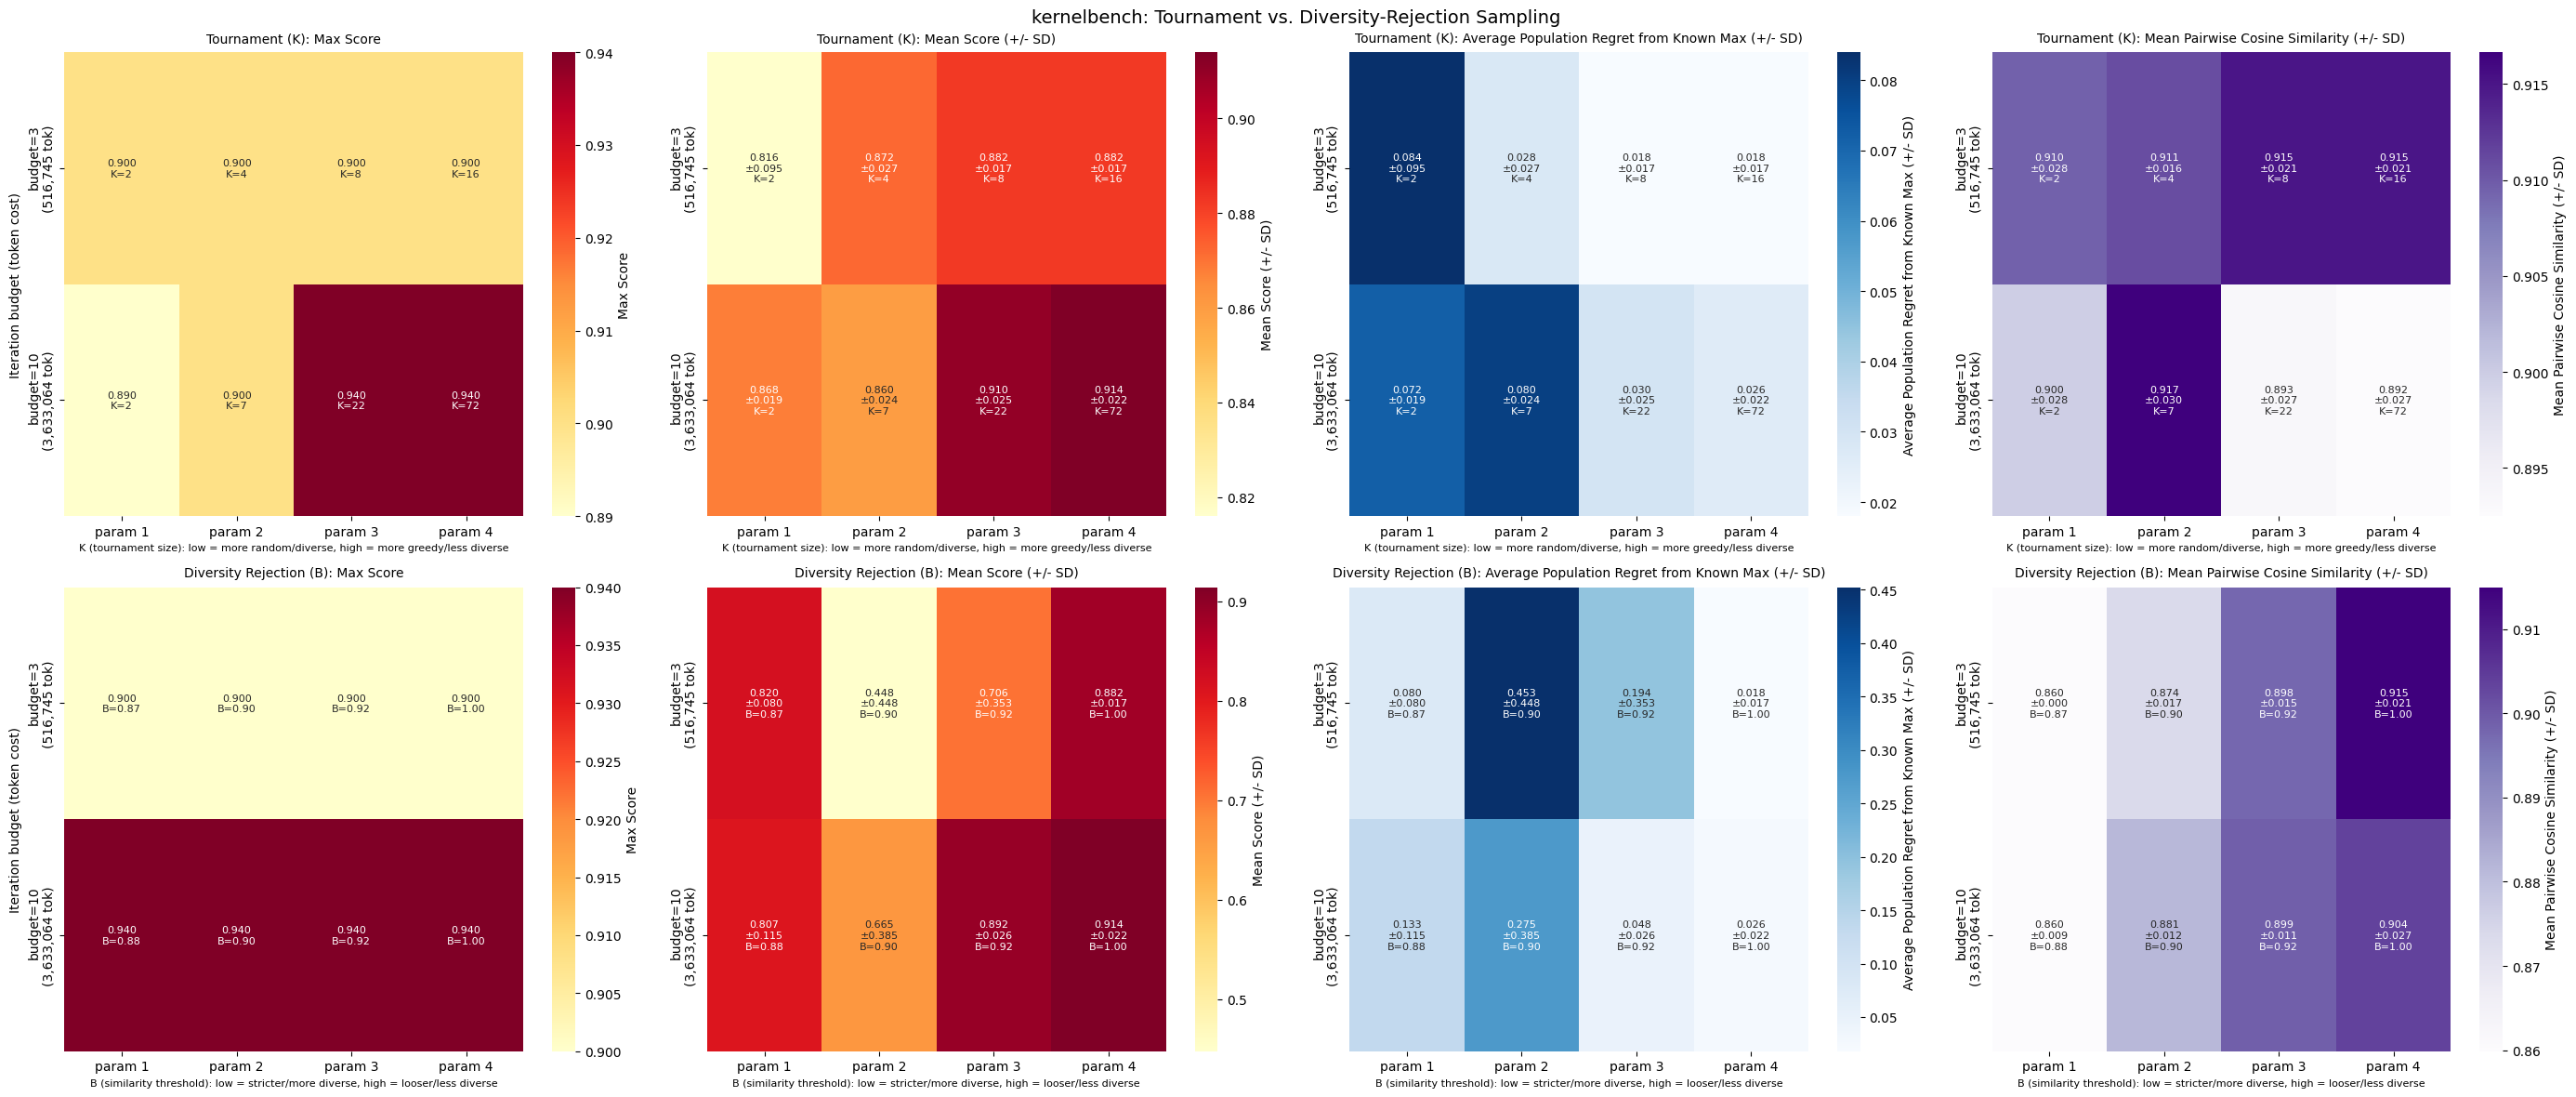

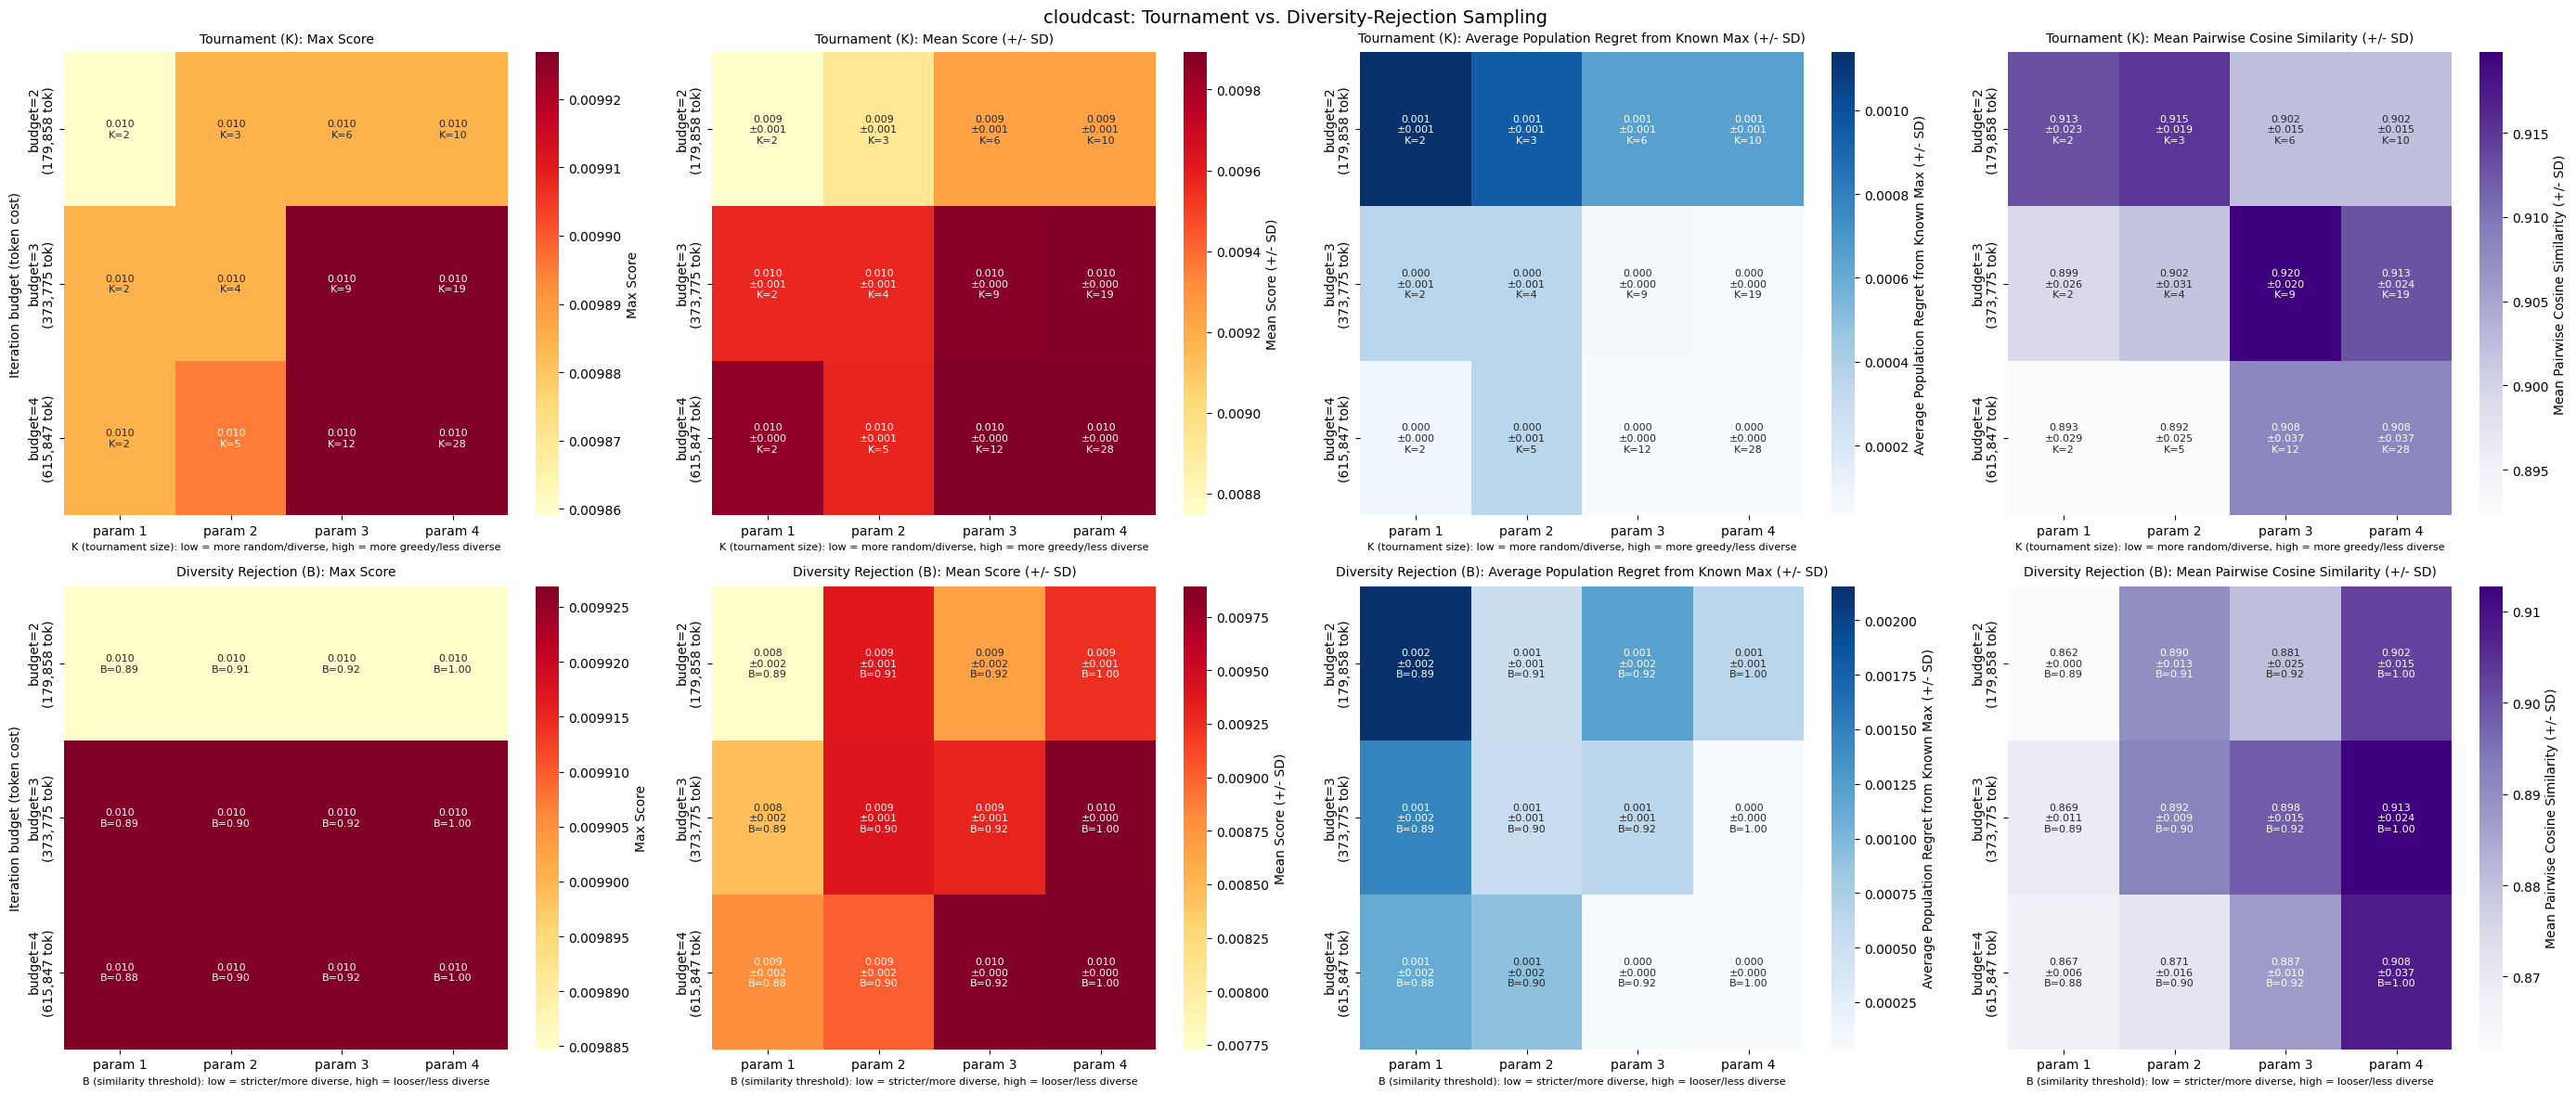

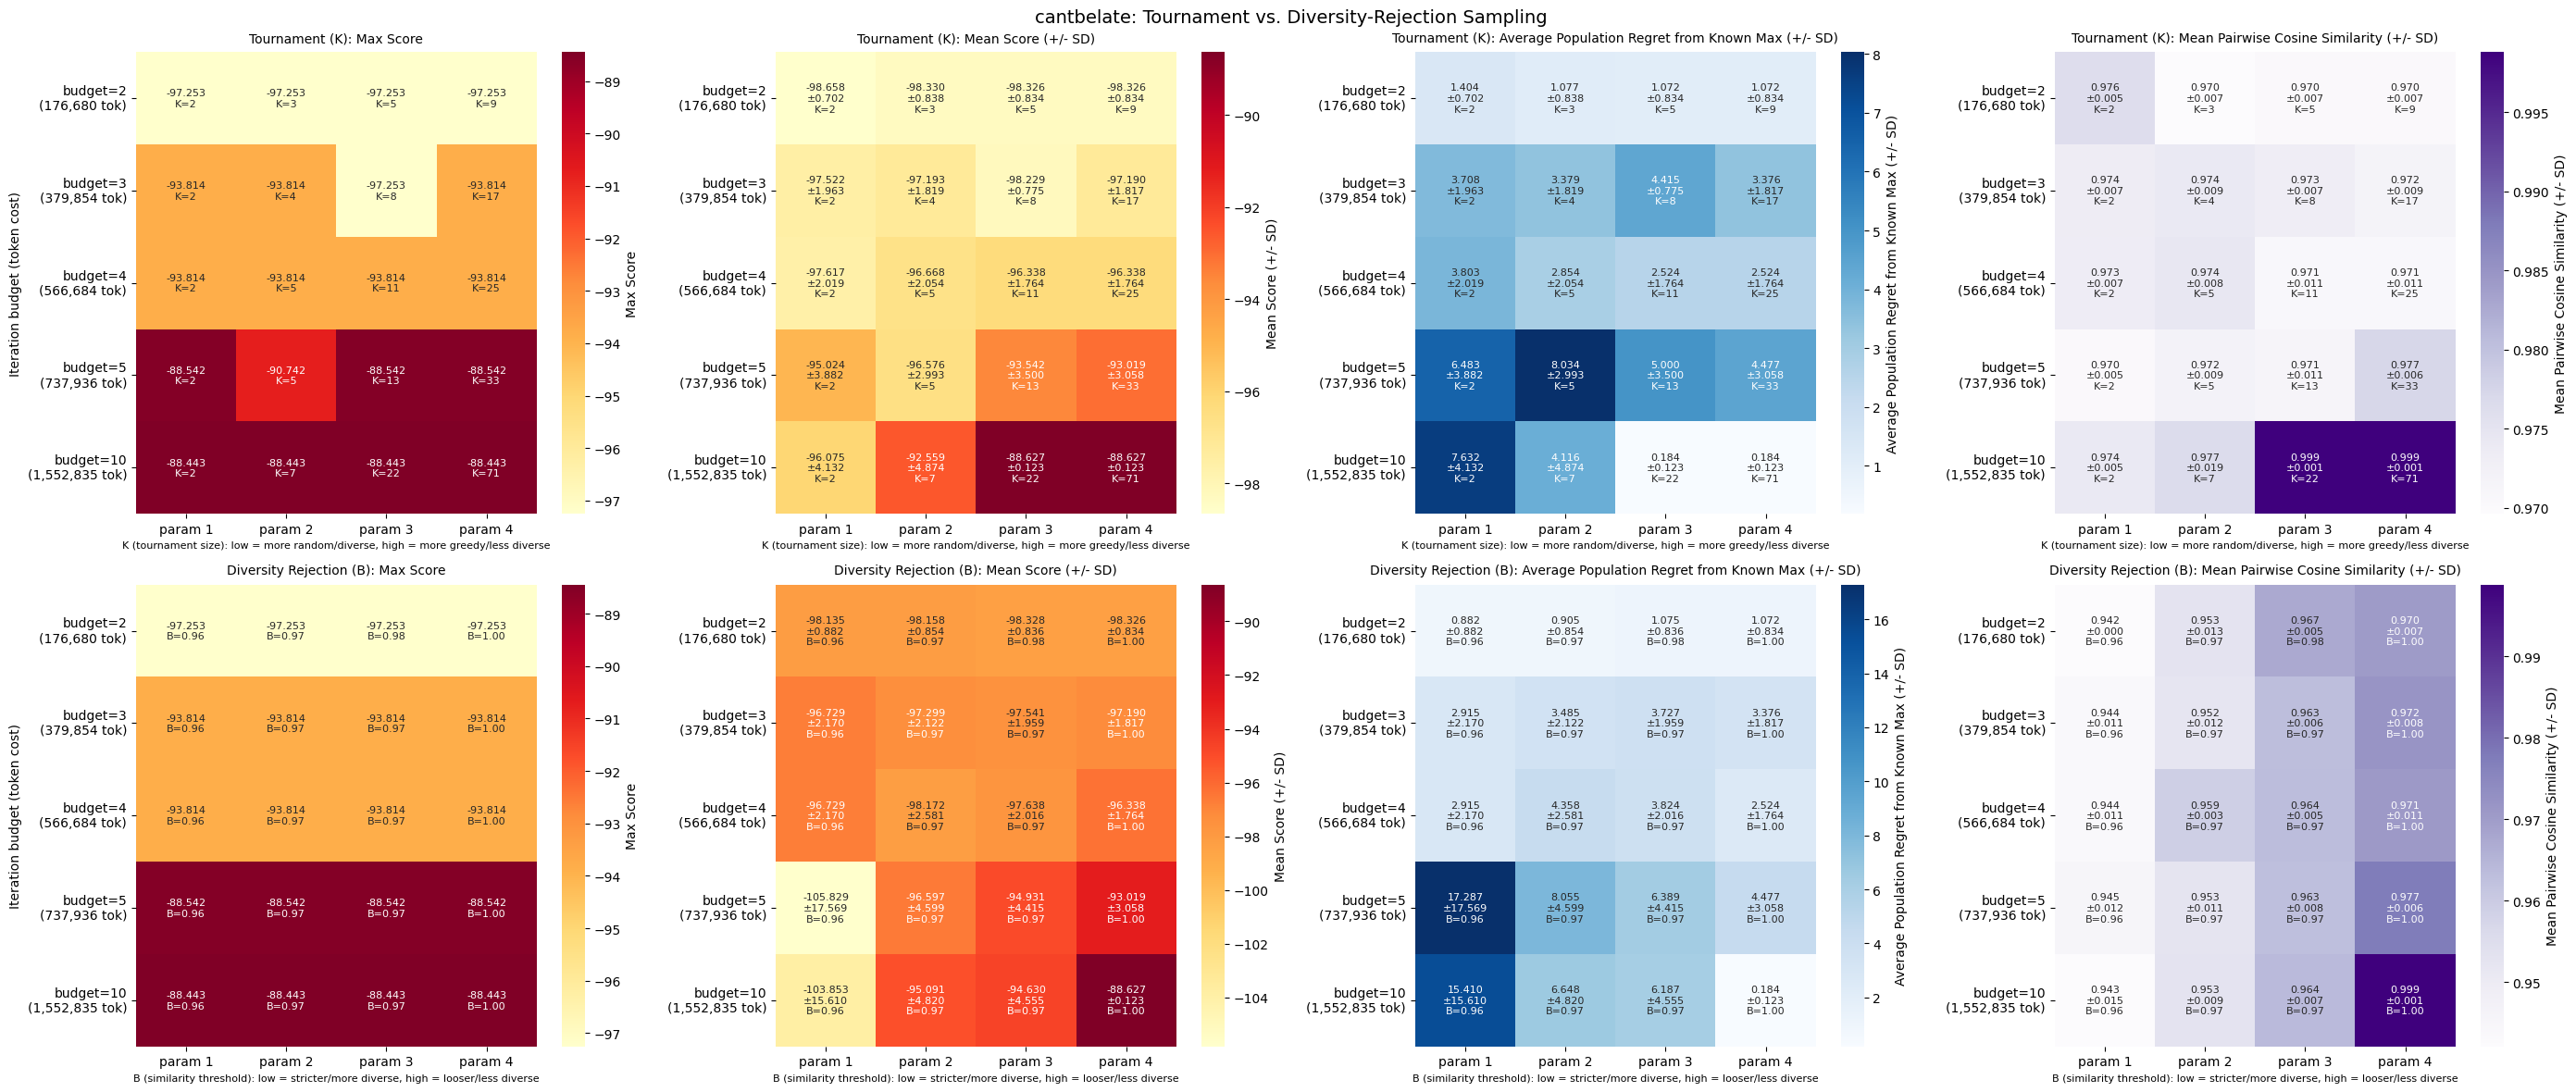

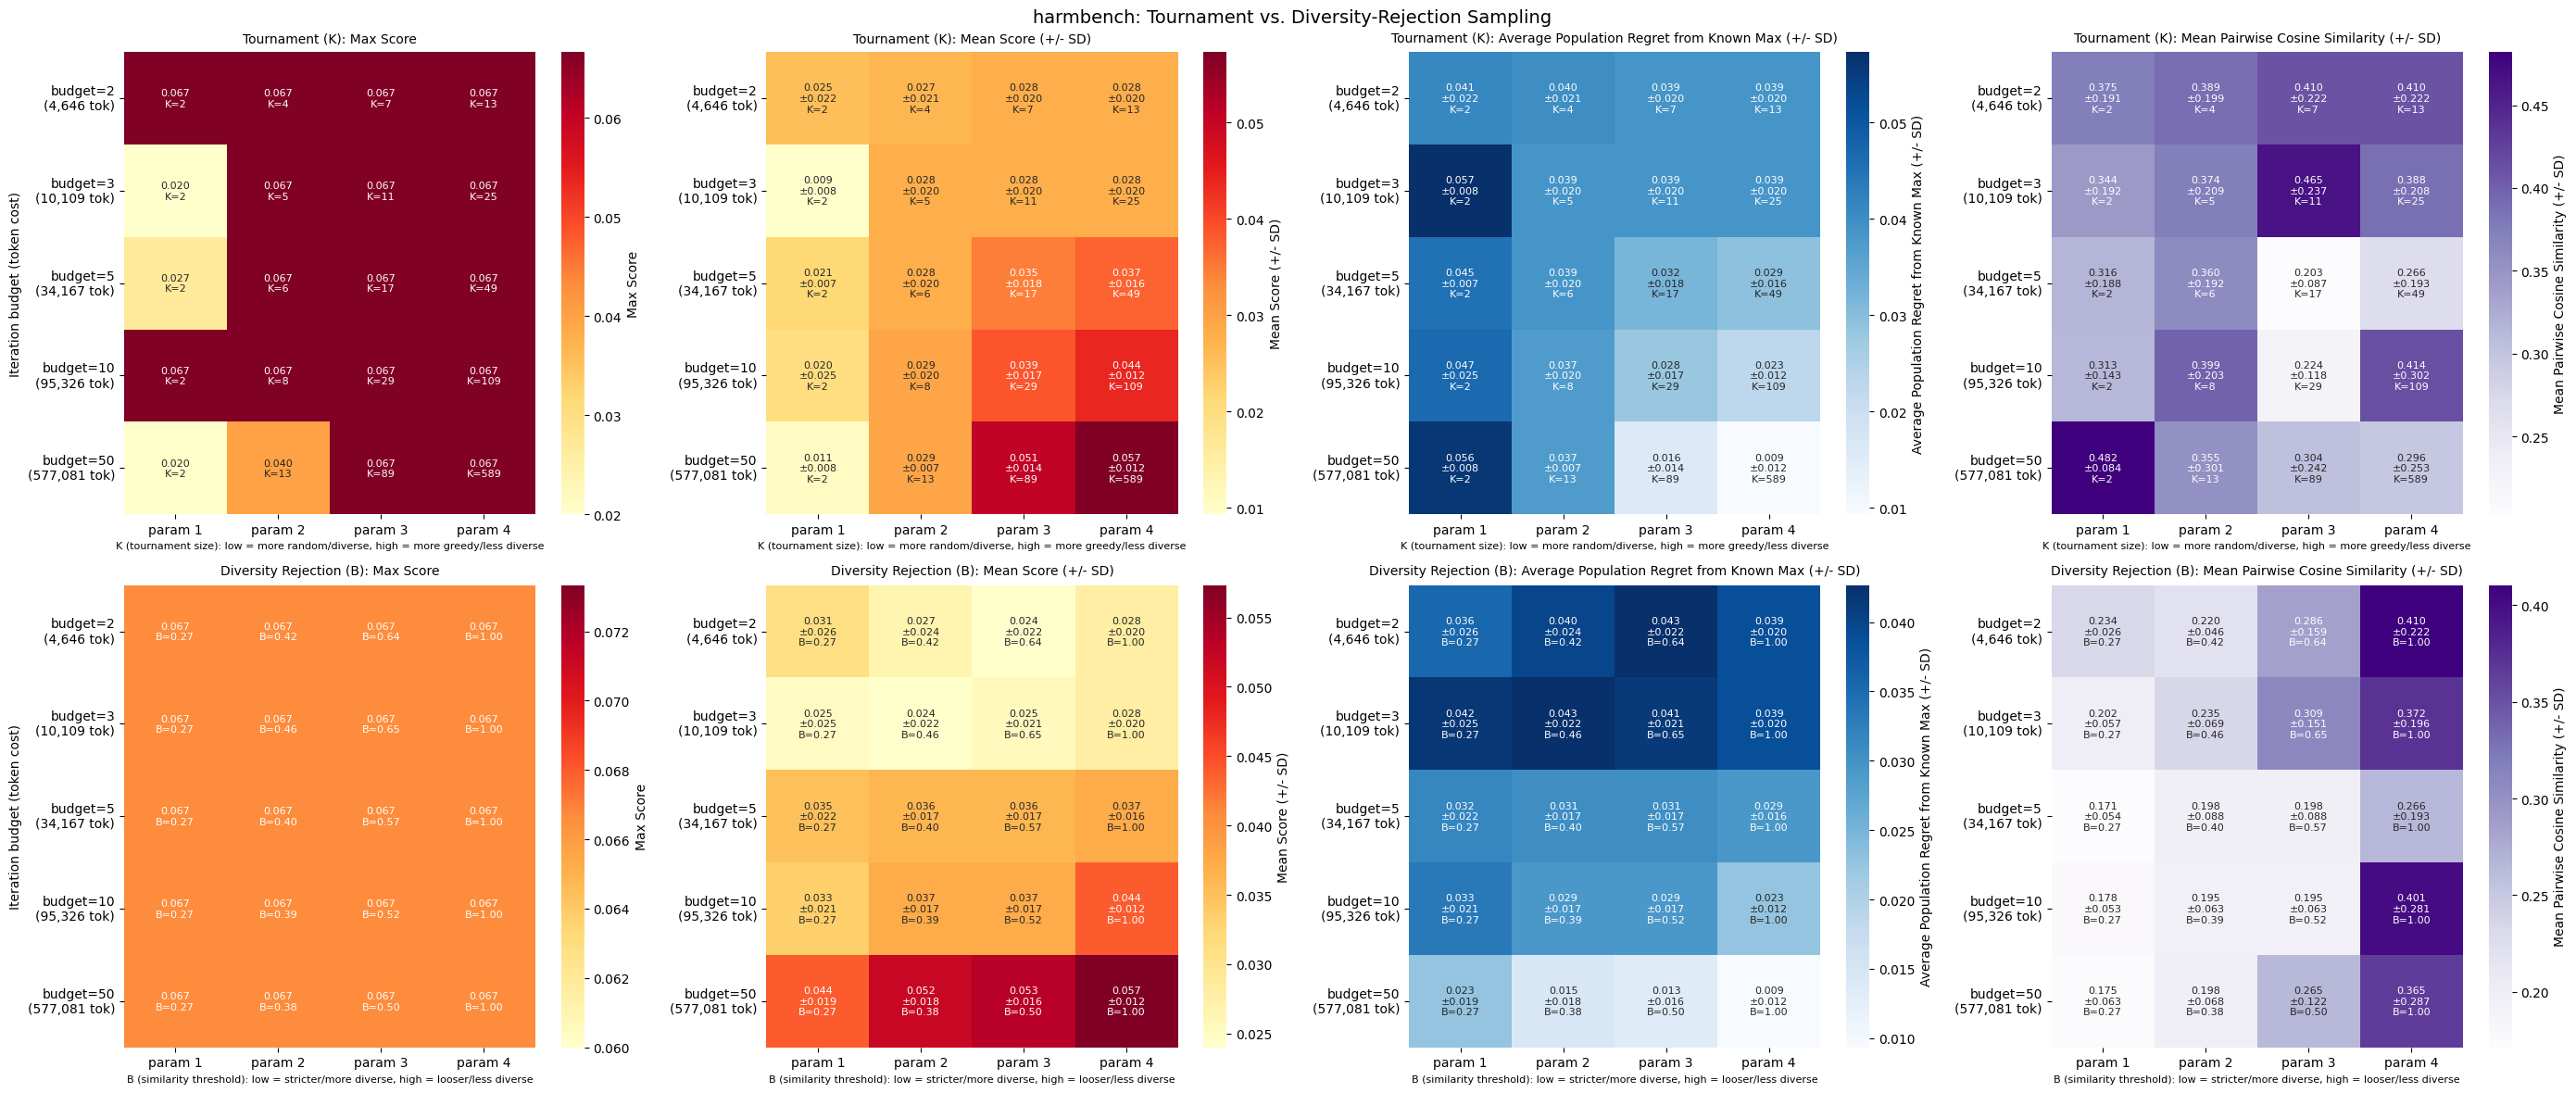

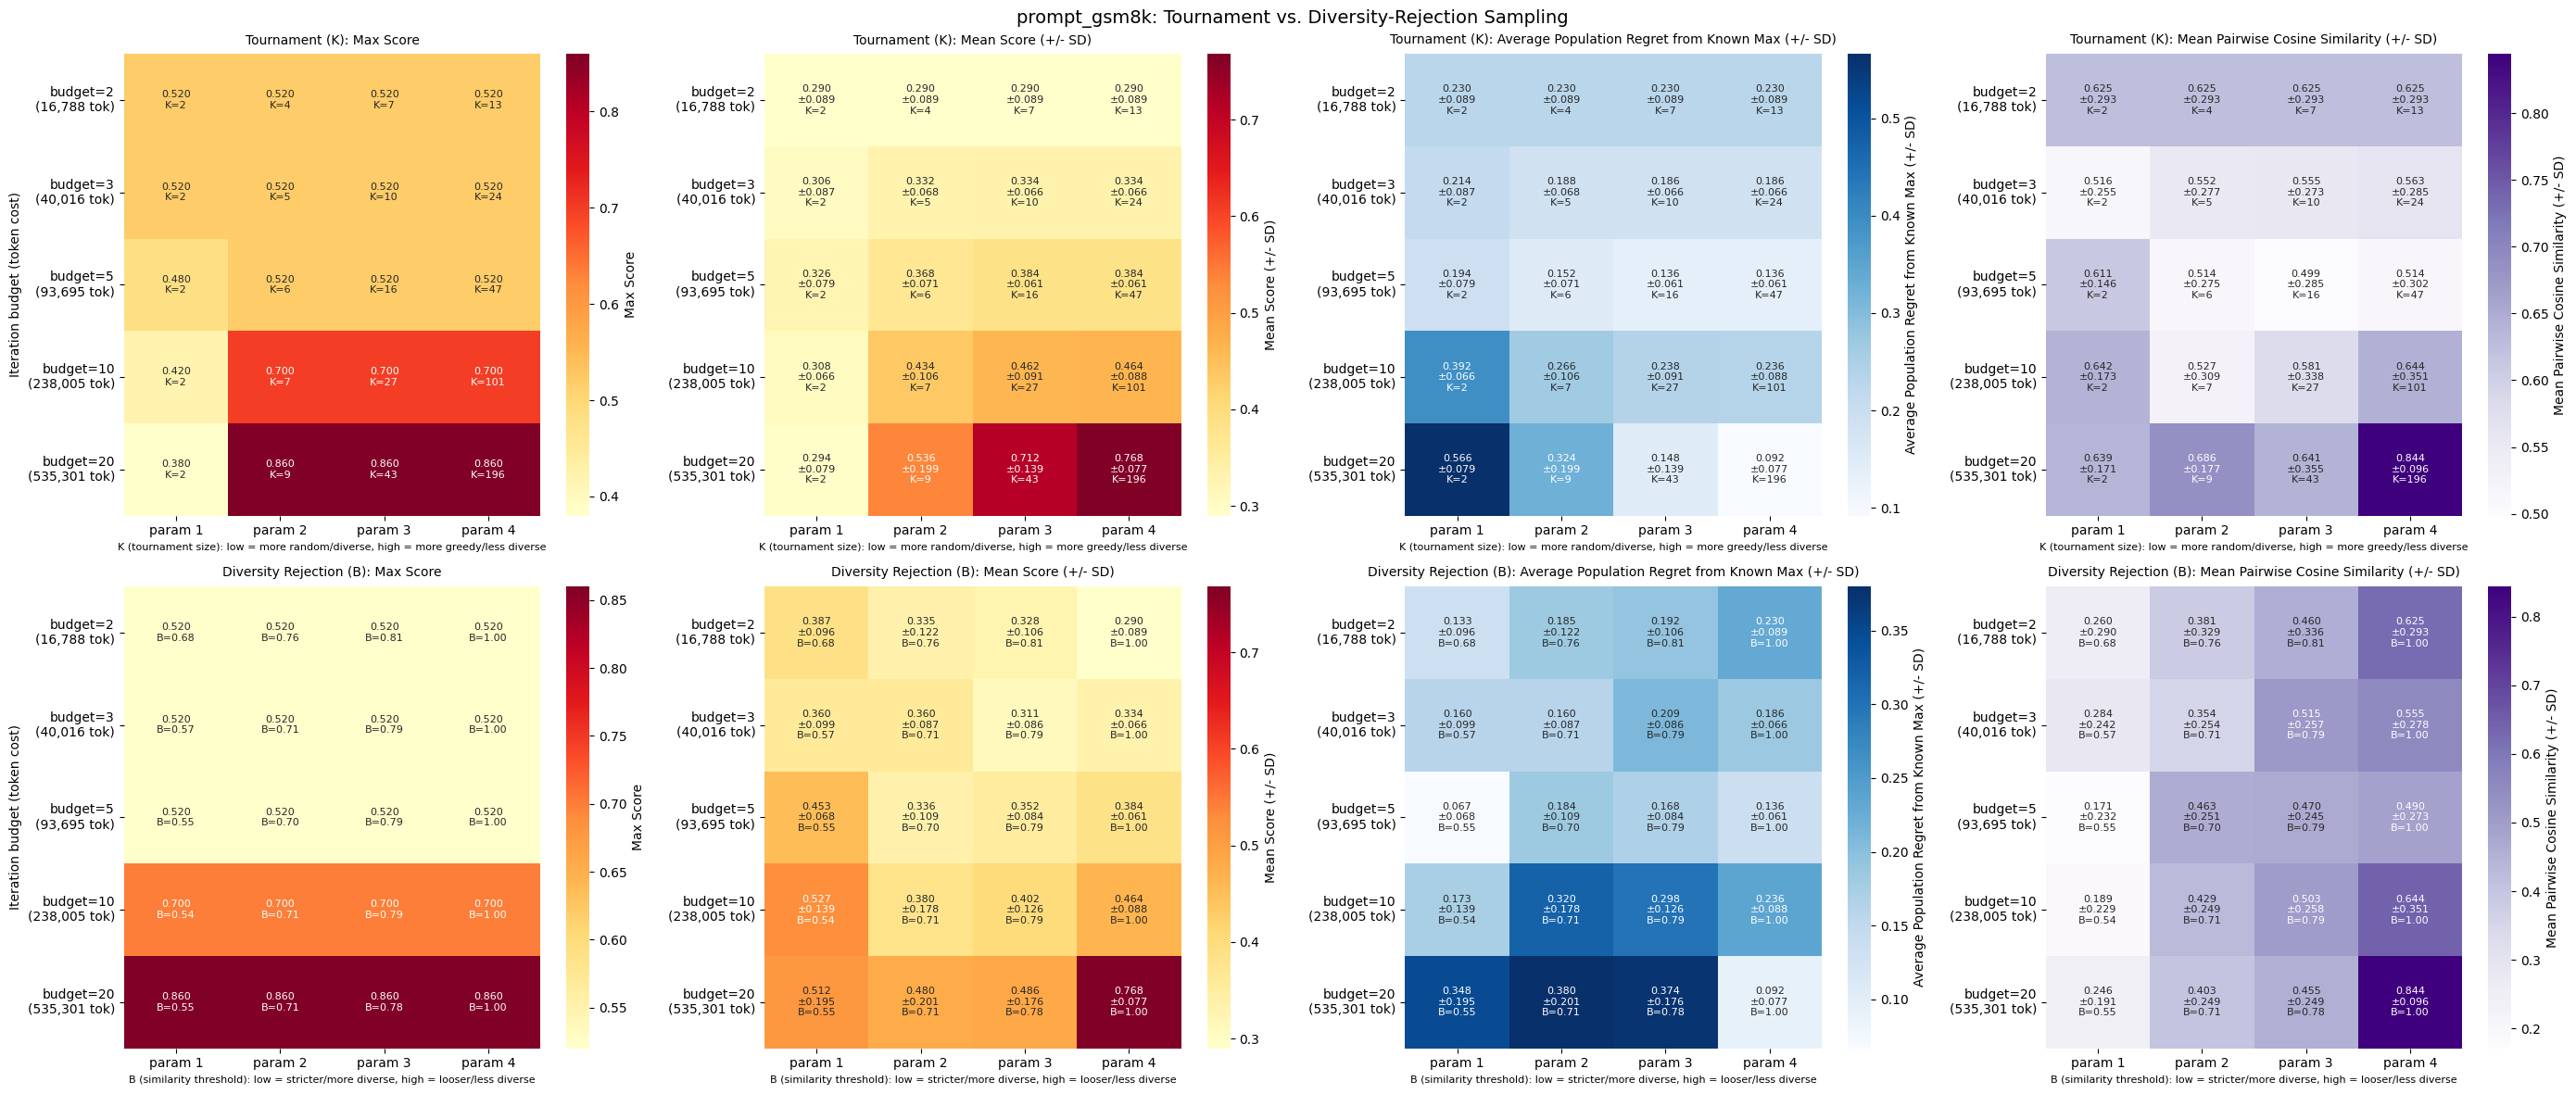

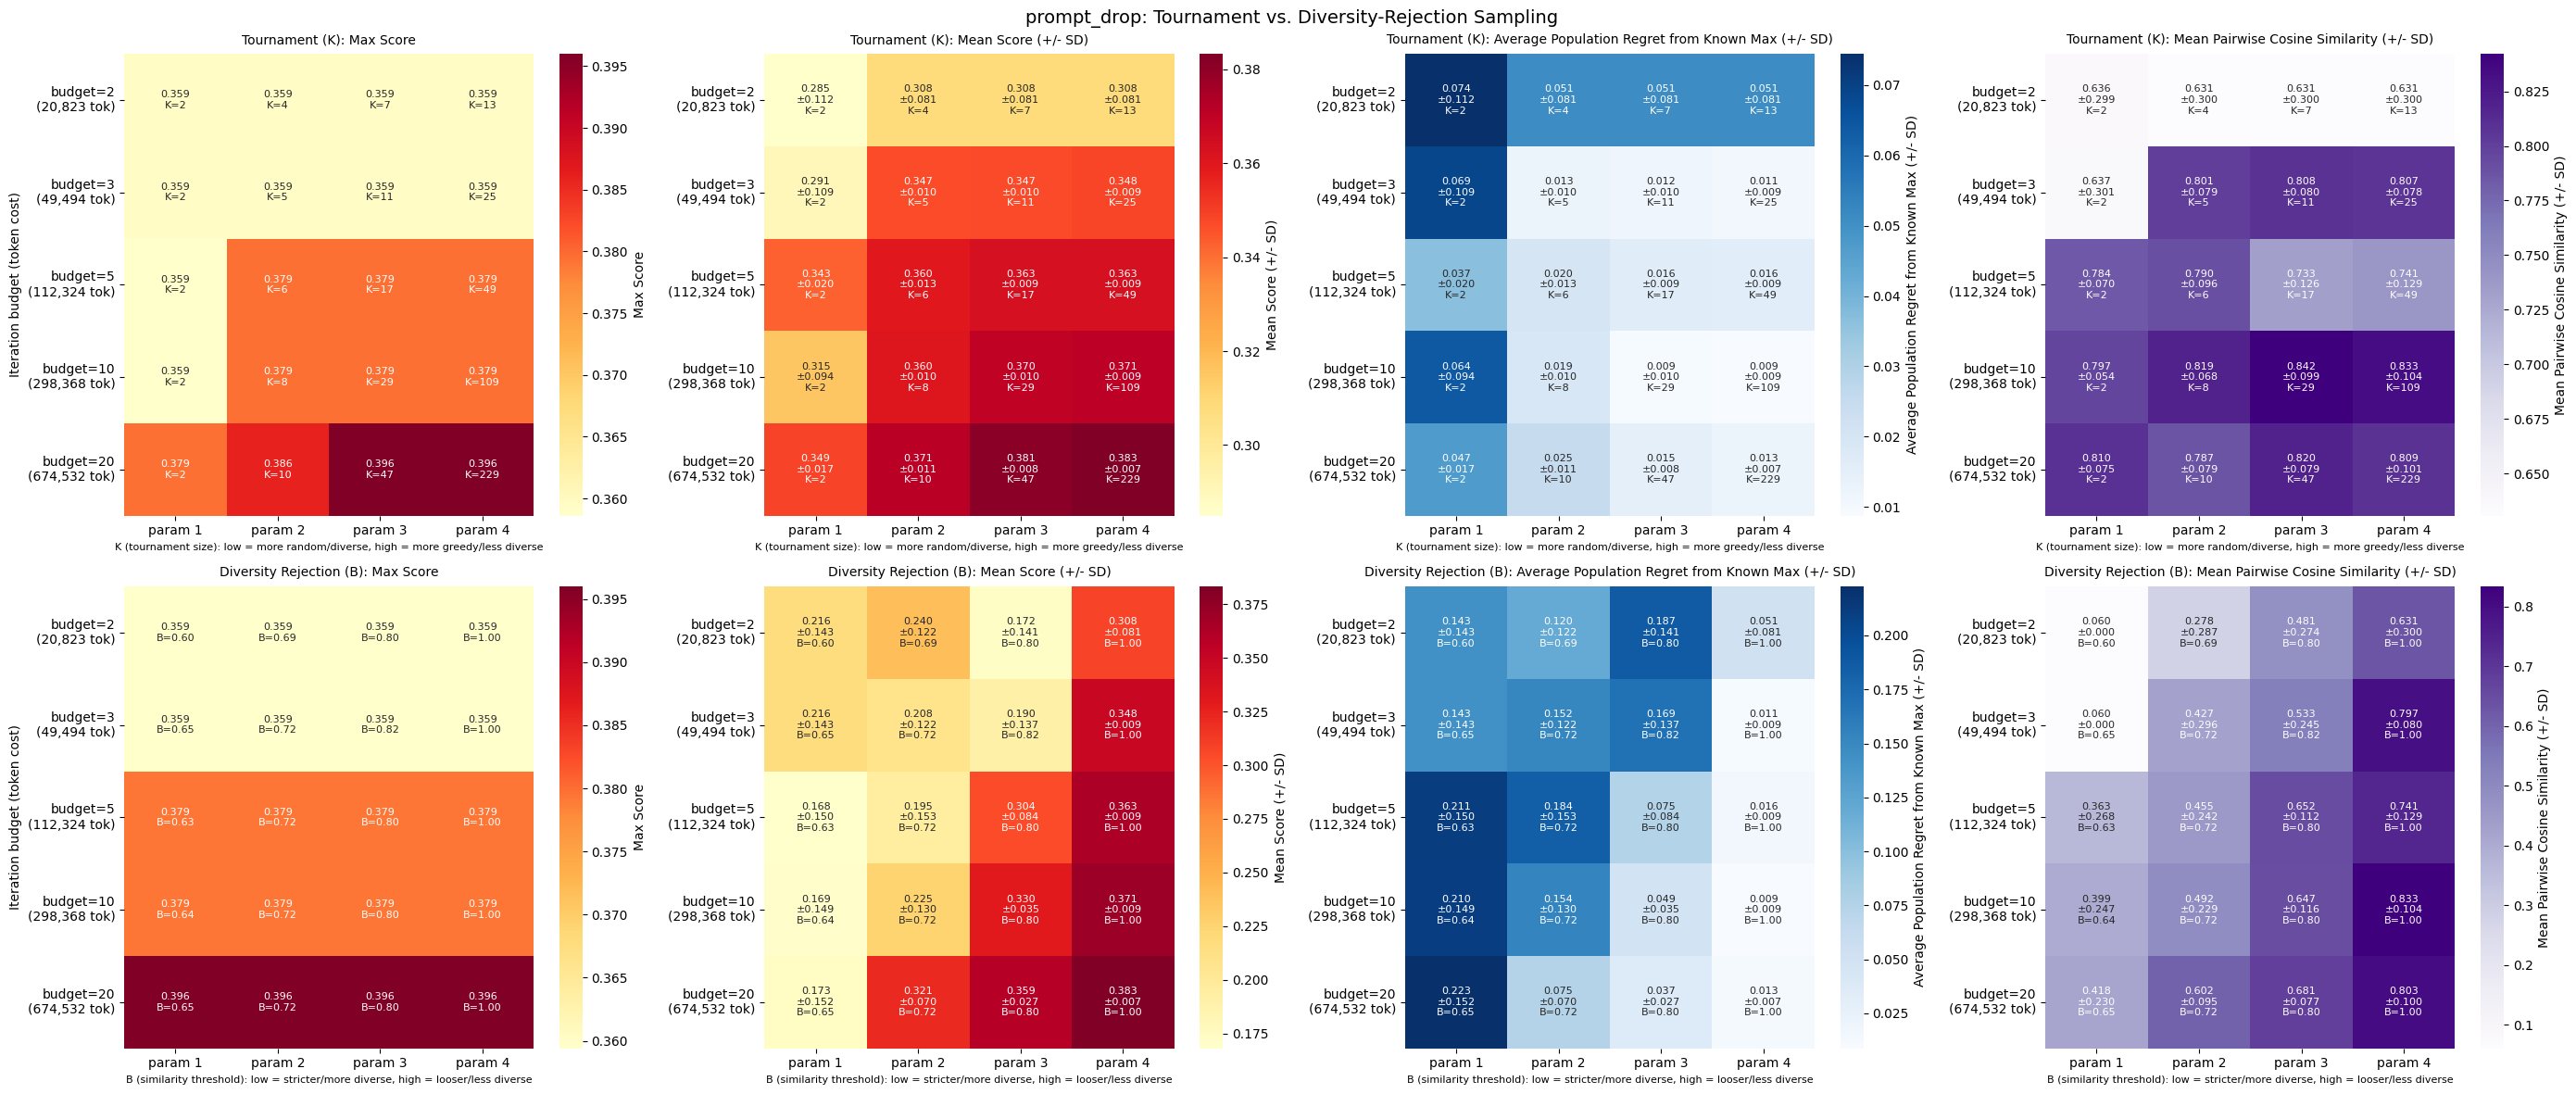

In [9]:
STRATEGIES = [
    ('tournament', 'Tournament (K)'),
    ('rejection', 'Diversity Rejection (B)'),
]

# (key, title, extractor -> (mean, sd), cmap) -- the 4 heatmap columns per strategy row.
METRIC_SPECS = [
    ('max_score', 'Max Score', lambda m: (m['max_score'], None), 'YlOrRd'),
    ('mean_score', 'Mean Score (+/- SD)', lambda m: (m['mean_score'], m['std_score']), 'YlOrRd'),
    (
        'regret',
        'Average Population Regret from Known Max (+/- SD)',
        lambda m: (m['mean_regret'], m['std_regret']),
        'Blues',
    ),
    (
        'diversity',
        'Mean Pairwise Cosine Similarity (+/- SD)',
        lambda m: (m['mean_sim'], m['std_sim']),
        'Purples',
    ),
]

# Per-strategy x-axis label -- names the swept param and its expected effect on diversity, since
# "low -> high" alone doesn't say what's being swept or which direction favors diversity: bigger
# tournaments (K) select more greedily (higher-scoring solutions tend to cluster, so this trends
# toward *less* diverse populations), while a looser similarity threshold (B) admits more
# near-duplicate candidates (also trending toward *less* diverse populations) -- so "low" means
# "more diverse" for both strategies, just via opposite mechanisms.
STRATEGY_XLABELS = {
    'tournament': 'K (tournament size): low = more random/diverse, high = more greedy/less diverse',
    'rejection': 'B (similarity threshold): low = stricter/more diverse, high = looser/less diverse',
}


def plot_task_heatmaps(task_name, task_results, budgets):
    """One figure per task: 2 rows (tournament / diversity-rejection) x 4 columns (max
    score, mean score, regret, diversity) of heatmaps. Each heatmap's rows are iteration
    budgets -- row label annotated with that budget's cumulative token cost -- and columns are
    the N_PARAM_VALUES swept K/B values; since the actual K or B differs per row (each is
    chosen from that row's own pool), it's annotated inside each cell alongside the metric.
    """
    present_budgets = [b for b in budgets if b in task_results]
    if not present_budgets:
        print(f'{task_name}: no results to plot.')
        return

    fig, axes = plt.subplots(2, 4, figsize=(28, 12))

    for row_idx, (strategy_key, strategy_label) in enumerate(STRATEGIES):
        y_labels = [
            f'budget={b}\n({task_results[b]["cost_tokens"]:,} tok)' for b in present_budgets
        ]

        for col_idx, (metric_key, metric_label, extract, cmap) in enumerate(METRIC_SPECS):
            ax = axes[row_idx, col_idx]

            value_rows, annot_rows = [], []
            for b in present_budgets:
                entries = task_results[b][strategy_key]
                value_row, annot_row = [], []
                for entry in entries:
                    if entry is None:
                        value_row.append(np.nan)
                        annot_row.append('n/a')
                        continue
                    mean_val, sd_val = extract(entry)
                    value_row.append(mean_val)
                    param_str = (
                        f'K={entry["param"]}'
                        if strategy_key == 'tournament'
                        else f'B={entry["param"]:.2f}'
                    )
                    sd_str = f'\n±{sd_val:.3f}' if sd_val is not None else ''
                    annot_row.append(f'{mean_val:.3f}{sd_str}\n{param_str}')
                # Pad to N_PARAM_VALUES columns in case a (task, budget) produced fewer entries.
                while len(value_row) < N_PARAM_VALUES:
                    value_row.append(np.nan)
                    annot_row.append('n/a')
                value_rows.append(value_row)
                annot_rows.append(annot_row)

            value_mat = np.array(value_rows, dtype=float)
            annot_mat = np.array(annot_rows)

            sns.heatmap(
                value_mat,
                annot=annot_mat,
                fmt='',
                cmap=cmap,
                ax=ax,
                yticklabels=y_labels,
                xticklabels=[f'param {i + 1}' for i in range(N_PARAM_VALUES)],
                annot_kws={'size': 8},
                cbar_kws={'label': metric_label},
            )
            ax.set_title(f'{strategy_label}: {metric_label}', fontsize=10, pad=8)
            ax.set_xlabel(STRATEGY_XLABELS[strategy_key], fontsize=8)
            ax.set_ylabel('Iteration budget (token cost)' if col_idx == 0 else '')

    fig.suptitle(f'{task_name}: Tournament vs. Diversity-Rejection Sampling', fontsize=14)
    plt.tight_layout()
    plt.show()


for task_name, cfg in TASK_BUDGET_CONFIGS.items():
    plot_task_heatmaps(task_name, results.get(task_name, {}), cfg['budgets'])